# 09 — Interpretable rules for high-variance regions

**Goal:** Find interpretable feature-based rules that **describe** discovered HH/HV regions in the test set. **Goal is to describe discovered HH/HV regions, not to predict future points.**

**Inputs:** Per-point multiplicity (variance), LISA HH labels, X_test and feature names.

**Labels:** HV_q (top q% variance), HH (LISA High-High), HV_only, HH_only.

**Metrics (descriptive region summaries):** *purity* = P(label=1 | rule region); *support* = # points in region; *recall* = coverage of positives; *lift* = purity / base_rate.

**Methods:** (1) Shallow decision tree surrogate, (2) L1 Logistic Regression, (3) Cluster HV then describe with tiny trees, (4) Subgroup discovery (beam search). Robustness: bootstrap OOB evaluation (no holdout) and permutation enrichment tests.

**Outputs:** `tables/rules_summary_{dataset}.csv`, `tables/rules_oob_summary_{dataset}.csv`, `tables/rules_permutation_pvals_{dataset}.csv`, `tables/rule_feature_stability_{dataset}.csv`, `tables/final_rules_{dataset}.csv`, `figures/rules_support_purity_{dataset}.pdf`, `figures/pca_hv_hh_{dataset}.pdf`.

In [1]:
# Imports and path setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, _tree
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import average_precision_score, silhouette_score

from data import load_dataset, make_preprocessor
from analysis.run_analysis import (
    load_P_test, load_split, load_meta,
    select_rashomon_global, pointwise_variance, run_spatial,
)
from analysis.preprocessing import get_transformed_test_features
from analysis.spatial import extract_hh_components

RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "figures"
TABLE_DIR = ROOT / "tables"
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

## Configuration

Set `dataset_name` to match a directory under `results/` (e.g. compas, german, breast_cancer).  
Set `SEED` to the run to use (e.g. 0). `q` = top q% for HV_q (default 10).

In [2]:
dataset_name = "compas"
SEED = 0
q = 10  # top q% highest variance -> HV_q
K = 25
k_nn = 30
run_dir = RESULTS_DIR / dataset_name / f"seed={SEED}"

## Load pipeline artifacts and define labels

Load X_test (preprocessed), feature names, per-point variance, and LISA HH mask for one run.

In [3]:
def get_feature_names_for_run(run_dir, dataset_name):
    """Return feature names after preprocessing (same order as get_transformed_test_features)."""
    split = load_split(run_dir)
    X, y, feature_info = load_dataset(dataset_name)
    preprocessor = make_preprocessor(feature_info, scale_numeric=True)
    train_idx = split["train"]
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    preprocessor.fit(X_train, y_train)
    return preprocessor.get_feature_names_out().tolist()


def load_run_data(run_dir, dataset_name, K=25, k_nn=30, seed=42):
    """Load X_test (array), feature_names, pointwise variance, HH_mask, and spatial W for components."""
    run_dir = Path(run_dir)
    X_test = get_transformed_test_features(run_dir, dataset_name)
    feature_names = get_feature_names_for_run(run_dir, dataset_name)
    if len(feature_names) != X_test.shape[1]:
        feature_names = [f"f{j}" for j in range(X_test.shape[1])]
    P_test = load_P_test(run_dir)
    idx = select_rashomon_global(run_dir, K=K)
    P_sel = P_test[idx]
    variance = pointwise_variance(P_sel, ddof=0)
    spatial = run_spatial(run_dir, X_test, K=K, k=k_nn, seed=seed)
    HH_mask = spatial["HH_mask"]
    W = spatial.get("W")
    return {
        "X_test": np.asarray(X_test, dtype=float),
        "feature_names": feature_names,
        "variance": variance,
        "HH_mask": HH_mask,
        "W": W,
        "n_test": X_test.shape[0],
    }


data = load_run_data(run_dir, dataset_name, K=K, k_nn=k_nn)
X_test = data["X_test"]
feature_names = data["feature_names"]
variance = data["variance"]
HH_mask = data["HH_mask"]
W = data["W"]
n_test = data["n_test"]
print(f"Run: {run_dir}")
print(f"n_test={n_test}, n_features={len(feature_names)}")
print(f"HH count: {HH_mask.sum()}")

Run: c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results\compas\seed=0
n_test=1443, n_features=12
HH count: 47


In [4]:
# Define labels: HV_q (top q% variance), HH (LISA High-High), HV_only, HH_only
n_high = max(1, int(np.ceil(n_test * q / 100)))
threshold_var = np.partition(variance, -n_high)[-n_high]
HV_q = variance >= threshold_var
HH = np.asarray(HH_mask, dtype=bool)
HV_only = HV_q & ~HH
HH_only = HH & ~HV_q
base_rate_hv = HV_q.mean()
base_rate_hh = HH.mean()
print(f"HV_q (top {q}%): {HV_q.sum()} points, base rate={base_rate_hv:.4f}")
print(f"HH: {HH.sum()} points, base rate={base_rate_hh:.4f}")
print(f"HV_only: {HV_only.sum()}, HH_only: {HH_only.sum()}")

HV_q (top 10%): 147 points, base rate=0.1019
HH: 47 points, base rate=0.0326
HV_only: 111, HH_only: 11


## Helper functions: rule extraction and metrics

In [5]:
def tree_to_rules_conditions(tree):
    """Extract structured conditions per positive leaf: list of list of (feat_idx, op, value)."""
    t = tree.tree_
    rules_conditions = []
    def recurse(node, conditions):
        if t.feature[node] == _tree.TREE_UNDEFINED:
            pred = int(t.value[node].argmax())
            if pred == 1 and conditions:
                rules_conditions.append(conditions[:])
            return
        feat_idx = int(t.feature[node])
        thresh = float(t.threshold[node])
        recurse(t.children_left[node], conditions + [(feat_idx, "<=", thresh)])
        recurse(t.children_right[node], conditions + [(feat_idx, ">", thresh)])
    recurse(0, [])
    return rules_conditions


def rule_to_string(conditions, feature_names):
    """Format structured conditions as human-readable rule text."""
    return " AND ".join([f"{feature_names[j]} {op} {v:.4g}" for j, op, v in conditions])


def rule_applies(X, rule_conditions):
    """
    rule_conditions: list of (feat_idx, op, value) with op in ('<=', '>').
    Return boolean array of shape (n_samples,) indicating which points satisfy the rule.
    """
    mask = np.ones(X.shape[0], dtype=bool)
    for (feat_idx, op, value) in rule_conditions:
        col = X[:, feat_idx]
        if op == "<=":
            mask &= col <= value
        else:
            mask &= col > value
    return mask


def rule_metrics(y_true, y_pred_rule, base_rate=None):
    """Descriptive region metrics: support, purity (= P(label=1|region)), recall, lift. y_true, y_pred_rule: 0/1."""
    y_true = np.asarray(y_true).ravel()
    y_pred_rule = np.asarray(y_pred_rule).ravel()
    support = int(np.sum(y_pred_rule))
    n = len(y_true)
    if support == 0:
        return {"support": 0, "purity": 0.0, "recall": 0.0, "lift": 0.0}
    tp = np.sum((y_true == 1) & (y_pred_rule == 1))
    base = max(1e-10, np.sum(y_true))
    purity = tp / support
    rec = tp / base
    br = base_rate if base_rate is not None else (base / n)
    lift = (purity / br) if br > 0 else 0.0
    return {"support": support, "purity": purity, "recall": rec, "lift": lift}

## Method 1: Shallow decision tree surrogate (descriptive)

Max depth 2–4, min_samples_leaf and ccp_alpha tuned; extract if-then rules from tree paths. Each rule = one positive leaf; metrics use that rule's region mask only.

In [6]:
def fit_tree_surrogate(X, y, feature_names, max_depth=3, min_samples_leaf=10, ccp_alpha=0.0):
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        ccp_alpha=ccp_alpha,
        class_weight="balanced",
        random_state=42,
    )
    clf.fit(X, y)
    conditions_list = tree_to_rules_conditions(clf)
    rules_with_masks = []
    for conds in conditions_list:
        rule_text = rule_to_string(conds, feature_names)
        mask = rule_applies(X, conds)
        rules_with_masks.append((rule_text, mask))
    return clf, rules_with_masks


def method1_tree(X, y, feature_names, max_depths=(2, 3, 4), min_leaf_range=(5, 10, 20), ccp_range=(0.0, 0.01)):
    """Returns (clf, list of (rule_text, mask)) so each rule has its own region for metrics."""
    best_pr_auc = -1
    best_clf = best_rules = None
    for md in max_depths:
        for msl in min_leaf_range:
            for ccp in ccp_range:
                clf, rules_w_masks = fit_tree_surrogate(X, y, feature_names, max_depth=md, min_samples_leaf=msl, ccp_alpha=ccp)
                if not rules_w_masks:
                    continue
                y_prob = clf.predict_proba(X)[:, 1]
                pr_auc = average_precision_score(y, y_prob)
                if pr_auc > best_pr_auc:
                    best_pr_auc = pr_auc
                    best_clf = clf
                    best_rules = rules_w_masks
    if best_clf is None:
        best_clf, best_rules = fit_tree_surrogate(X, y, feature_names, max_depth=3, min_samples_leaf=10, ccp_alpha=0.0)
    return best_clf, best_rules

## Method 2: L1 Logistic Regression

Standardize numeric features; report top coefficients and direction. ElasticNet (l1_ratio) optional.

In [7]:
def method2_l1_logreg(X, y, feature_names, C=0.1, l1_ratio=1.0):
    """Returns (clf, scaler, rule_text, region_mask, coef_dict). Region = predicted positive (descriptive)."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    clf = LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        C=C,
        l1_ratio=l1_ratio,
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    )
    clf.fit(Xs, y)
    coef = clf.coef_.ravel()
    idx = np.argsort(np.abs(coef))[::-1]
    top_k = min(15, len(feature_names))
    rule_parts = [f"{feature_names[idx[i]]}={coef[idx[i]]:+.4g}" for i in range(top_k)]
    rule_text = " | ".join(rule_parts)
    region_mask = (clf.predict_proba(Xs)[:, 1] >= 0.5)
    return clf, scaler, rule_text, region_mask, dict(zip([feature_names[i] for i in idx], coef[idx]))

## Method 3: Cluster HV points then describe clusters

Cluster only HV_q points (PCA then kmeans; k by silhouette). For each cluster, fit a tiny tree (depth ≤ 3) to separate cluster vs rest and extract rules.

In [8]:
def method3_cluster_describe(X, y_hv, feature_names, n_components=10, k_range=(2, 6), max_tree_depth=3):
    """For each cluster, fit tiny tree; extract rules as (conditions) and compute per-rule mask via rule_applies."""
    X_hv = X[y_hv]
    if X_hv.shape[0] < 5:
        return []
    n_comp = min(n_components, X_hv.shape[0] - 1, X_hv.shape[1])
    if n_comp < 1:
        return []
    pca = PCA(n_components=n_comp, random_state=42).fit(X_hv)
    Xp = pca.transform(X_hv)
    best_k = 2
    best_sil = -1
    for k in range(max(k_range[0], 2), min(k_range[1] + 1, X_hv.shape[0])):
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xp)
        sil = silhouette_score(Xp, km.labels_)
        if sil > best_sil:
            best_sil = sil
            best_k = k
    km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xp)
    cluster_labels_hv = km.labels_
    rules_list = []  # list of (rule_text, rule_mask)
    for c in range(best_k):
        in_c = np.zeros(X.shape[0], dtype=bool)
        in_c[y_hv] = cluster_labels_hv == c
        y_c = in_c.astype(int)
        if y_c.sum() < 3:
            continue
        tree_c = DecisionTreeClassifier(max_depth=max_tree_depth, min_samples_leaf=2, class_weight="balanced", random_state=42)
        tree_c.fit(X, y_c)
        conditions_list = tree_to_rules_conditions(tree_c)
        for conds in conditions_list:
            rule_text = f"Cluster{c}: " + rule_to_string(conds, feature_names)
            rule_mask = rule_applies(X, conds)
            rules_list.append((rule_text, rule_mask))
    return rules_list

## Method 4: Subgroup discovery (beam search over conjunctions)

Search for rules (feature threshold conditions) that maximize lift = P(HV|rule)/P(HV). Enforce min_support and max_conditions; output top-K rules.

In [9]:
def beam_search_rules(X, y, feature_names, min_support=10, max_conditions=4, beam_width=20, top_k=10):
    """Simple beam search: extend conjunctions by one condition; keep best by lift."""
    n, n_feat = X.shape
    base_rate = max(1e-10, y.sum() / n)
    # candidates: list of (conditions, mask), conditions = [(feat_idx, op, value), ...]
    candidates = [([], np.ones(n, dtype=bool))]
    best_rules = []  # (rule_text, mask, lift, support, precision)
    seen = set()
    for _ in range(max_conditions):
        new_candidates = []
        for conds, mask in candidates:
            support = np.sum(mask)
            if support < min_support:
                continue
            tp = np.sum(y[mask])
            prec = tp / support
            lift = prec / base_rate
            key = tuple(sorted(conds))
            if key not in seen:
                seen.add(key)
                rule_str = " AND ".join([f"{feature_names[j]} {op} {v:.4g}" for j, op, v in conds])
                best_rules.append((rule_str, mask.copy(), conds[:], lift, int(support), prec))
            for j in range(n_feat):
                col = X[:, j]
                for val in np.percentile(col, [25, 50, 75]):
                    for op, thresh in [("<=", val), (">", val)]:
                        if op == "<=":
                            new_mask = mask & (col <= thresh)
                        else:
                            new_mask = mask & (col > thresh)
                        if np.sum(new_mask) >= min_support:
                            new_conds = conds + [(j, op, thresh)]
                            new_candidates.append((new_conds, new_mask))
        if not new_candidates:
            break
        # keep top by lift
        scored = []
        for conds, mask in new_candidates:
            s = np.sum(mask)
            if s < min_support:
                continue
            lift = (np.sum(y[mask]) / s) / base_rate
            scored.append((lift, conds, mask))
        scored.sort(key=lambda x: -x[0])
        candidates = [(c, m) for _, c, m in scored[:beam_width]]
    best_rules.sort(key=lambda x: -x[3])  # sort by lift (index 3; 2 is conds)
    return [(r[0], r[1], r[2], r[3], r[4], r[5]) for r in best_rules[:top_k]]  # (text, mask, conds, lift, support, purity)

## Run all methods and build descriptive region tables

For each method and label (HV_q, HH), produce: rule text, support, **purity** (= P(label=1|region)), recall, lift. No holdout: metrics describe the region on the same data used to define it.

In [10]:
def run_all_methods(X, feature_names, labels_dict):
    """Returns (rows for summary table, rules_with_masks for OOB/permutation/final selection).
    rules_with_masks: list of (label, method, rule_text, mask, support, purity, recall, lift)."""
    rows = []
    rules_with_masks = []
    for label_name, y in labels_dict.items():
        y = np.asarray(y, dtype=int)
        if y.sum() == 0:
            continue
        base_rate = y.sum() / len(y)
        # Method 1: Tree (one row per positive-leaf rule, each with its own mask)
        _, tree_rules_w_masks = method1_tree(X, y, feature_names)
        for rule_text, mask in tree_rules_w_masks:
            m = rule_metrics(y, mask, base_rate=base_rate)
            rows.append({"method": "tree", "label": label_name, "rule": rule_text[:300], **m})
            rules_with_masks.append((label_name, "tree", rule_text[:300], mask, m["support"], m["purity"], m["recall"], m["lift"]))
        if not tree_rules_w_masks:
            m = rule_metrics(y, np.zeros(X.shape[0], dtype=bool), base_rate=base_rate)
            rows.append({"method": "tree", "label": label_name, "rule": "(no positive leaf)", **m})
        # Method 2: L1 LogReg (one region = predicted positive)
        _, _, rule_text, region_mask, _ = method2_l1_logreg(X, y, feature_names)
        m = rule_metrics(y, region_mask, base_rate=base_rate)
        rows.append({"method": "l1_logreg", "label": label_name, "rule": rule_text[:300], **m})
        rules_with_masks.append((label_name, "l1_logreg", rule_text[:300], region_mask, m["support"], m["purity"], m["recall"], m["lift"]))
        # Method 3: Cluster-describe (one row per rule with its own mask)
        cluster_rules = method3_cluster_describe(X, y.astype(bool), feature_names)
        for rule_text, rule_mask in cluster_rules:
            m = rule_metrics(y, rule_mask, base_rate=base_rate)
            rows.append({"method": "cluster_describe", "label": label_name, "rule": rule_text[:300], **m})
            rules_with_masks.append((label_name, "cluster_describe", rule_text[:300], rule_mask, m["support"], m["purity"], m["recall"], m["lift"]))
        if not cluster_rules:
            m = rule_metrics(y, np.zeros(X.shape[0], dtype=bool), base_rate=base_rate)
            rows.append({"method": "cluster_describe", "label": label_name, "rule": "(no clusters)", **m})
        # Method 4: Beam search (top-K rules; prec = purity)
        beam = beam_search_rules(X, y, feature_names, min_support=10, max_conditions=4, top_k=5)
        for rule_text, mask, _conds, lift, support, purity in beam:
            rec = np.sum(y[mask]) / max(1, y.sum())
            rows.append({"method": "beam_search", "label": label_name, "rule": rule_text[:300],
                         "support": support, "purity": purity, "recall": rec, "lift": lift})
            rules_with_masks.append((label_name, "beam_search", rule_text[:300], mask, support, purity, rec, lift))
    return rows, rules_with_masks

In [11]:
labels_dict = {"HV_q": HV_q.astype(int), "HH": HH.astype(int)}
rules_rows, rules_with_masks = run_all_methods(X_test, feature_names, labels_dict)
rules_summary = pd.DataFrame(rules_rows)
for col in ["support", "purity", "recall", "lift"]:
    if col not in rules_summary.columns:
        rules_summary[col] = 0.0
if "precision" in rules_summary.columns:
    rules_summary["purity"] = rules_summary["precision"]
rules_summary

,method,label,rule,support,purity,recall,lift
0,tree,HV_q,num__priors_count <= 1.049 AND num__age <= -1....,31,0.612903,0.129252,6.016458
1,tree,HV_q,num__priors_count <= 1.049 AND num__age <= -1....,12,1.000000,0.081633,9.816327
2,tree,HV_q,num__priors_count <= 1.049 AND num__age <= -1....,37,0.324324,0.081633,3.183673
3,tree,HV_q,num__priors_count <= 1.049 AND num__age > -1.0...,66,0.166667,0.074830,1.636054
4,tree,HV_q,num__priors_count <= 1.049 AND num__age > -1.0...,5,0.200000,0.006803,1.963265
5,tree,HV_q,num__priors_count <= 1.049 AND num__age > -1.0...,11,0.727273,0.054422,7.139147
6,tree,HV_q,num__priors_count > 1.049 AND num__age <= -0.2...,9,0.111111,0.006803,1.090703
7,tree,HV_q,num__priors_count > 1.049 AND num__age <= -0.2...,5,0.400000,0.013605,3.926531
8,tree,HV_q,num__priors_count > 1.049 AND num__age > -0.27...,33,0.484848,0.108844,4.759431
9,tree,HV_q,num__priors_count > 1.049 AND num__age > -0.27...,67,0.179104,0.081633,1.758148


In [12]:
# Optional: PR-AUC (descriptive context; no holdout)
def compute_pr_auc(X, y, feature_names):
    y = np.asarray(y, dtype=int)
    if y.sum() < 2:
        return None
    tree_clf, _ = method1_tree(X, y, feature_names)
    y_prob_tree = tree_clf.predict_proba(X)[:, 1]
    log_clf, scaler, _, _, _ = method2_l1_logreg(X, y, feature_names)
    y_prob_log = log_clf.predict_proba(scaler.transform(X))[:, 1]
    return {"tree": average_precision_score(y, y_prob_tree), "l1_logreg": average_precision_score(y, y_prob_log)}

pr_auc_hv = compute_pr_auc(X_test, HV_q.astype(int), feature_names)
pr_auc_hh = compute_pr_auc(X_test, HH.astype(int), feature_names)
print("PR-AUC (descriptive): HV_q:", pr_auc_hv, "HH:", pr_auc_hh)

PR-AUC (descriptive): HV_q: {'tree': 0.6322167104206078, 'l1_logreg': 0.43870950681951104} HH: {'tree': 0.8161715506340267, 'l1_logreg': 0.6839099891628118}


## B) Bootstrap OOB robustness (no holdout)

For each method: B bootstraps; fit on in-bag, evaluate region metrics on **in-bag** (descriptive) and **OOB** (robustness). Save per-rule OOB: mean/median/IQR of purity, lift, support.

In [13]:
B_OOB = 50
rng_oob = np.random.RandomState(42)
n = X_test.shape[0]
oob_rows = []

for label_name, y in [("HV_q", HV_q.astype(int)), ("HH", HH.astype(int))]:
    y = np.asarray(y)
    if y.sum() == 0:
        continue
    base_rate = y.sum() / len(y)
    for b in range(B_OOB):
        in_bag = rng_oob.choice(n, size=n, replace=True)
        oob = np.array([i for i in range(n) if i not in in_bag], dtype=int)
        if len(oob) < 10:
            continue
        X_ib, y_ib = X_test[in_bag], y[in_bag]
        X_oob, y_oob = X_test[oob], y[oob]
        # Tree: get conditions per positive leaf, apply to OOB
        clf, rules_w_masks = method1_tree(X_ib, y_ib, feature_names)
        conds_list = tree_to_rules_conditions(clf)
        for rk, (_, mask_ib) in enumerate(rules_w_masks):
            if rk < len(conds_list):
                mask_oob = rule_applies(X_oob, conds_list[rk])
            else:
                mask_oob = np.zeros(len(oob), dtype=bool)
            s_ib = int(np.sum(mask_ib))
            s_oob = int(np.sum(mask_oob))
            pur_ib = np.sum(y_ib[mask_ib]) / s_ib if s_ib > 0 else 0.0
            pur_oob = np.sum(y_oob[mask_oob]) / s_oob if s_oob > 0 else 0.0
            lift_oob = pur_oob / base_rate if s_oob > 0 else 0.0
            oob_rows.append({"method": "tree", "label": label_name, "bootstrap": b, "rule_rank": rk,
                "in_bag_support": s_ib, "in_bag_purity": pur_ib, "oob_support": s_oob, "oob_purity": pur_oob, "oob_lift": lift_oob})
        # LogReg: one region
        log_clf, scaler, _, region_ib, _ = method2_l1_logreg(X_ib, y_ib, feature_names)
        region_oob = (log_clf.predict_proba(scaler.transform(X_oob))[:, 1] >= 0.5)
        s_ib = int(np.sum(region_ib))
        s_oob = int(np.sum(region_oob))
        pur_ib = np.sum(y_ib[region_ib]) / s_ib if s_ib else 0.0
        pur_oob = np.sum(y_oob[region_oob]) / s_oob if s_oob else 0.0
        lift_oob = pur_oob / base_rate if s_oob else 0.0
        oob_rows.append({"method": "l1_logreg", "label": label_name, "bootstrap": b, "rule_rank": 0,
            "in_bag_support": s_ib, "in_bag_purity": pur_ib, "oob_support": s_oob, "oob_purity": pur_oob, "oob_lift": lift_oob})
        # Beam: (rule_text, mask, conds, lift, support, purity); apply conds to OOB
        beam = beam_search_rules(X_ib, y_ib, feature_names, min_support=10, max_conditions=3, top_k=3)
        for rk, (_, mask_ib, conds, _lift, s_ib, pur_ib) in enumerate(beam):
            mask_oob = rule_applies(X_oob, conds)
            s_oob = int(np.sum(mask_oob))
            pur_oob = np.sum(y_oob[mask_oob]) / s_oob if s_oob else 0.0
            lift_oob = pur_oob / base_rate if s_oob else 0.0
            oob_rows.append({"method": "beam_search", "label": label_name, "bootstrap": b, "rule_rank": rk,
                "in_bag_support": s_ib, "in_bag_purity": pur_ib, "oob_support": s_oob, "oob_purity": pur_oob, "oob_lift": lift_oob})
        if not beam:
            oob_rows.append({"method": "beam_search", "label": label_name, "bootstrap": b, "rule_rank": 0,
                "in_bag_support": 0, "in_bag_purity": 0.0, "oob_support": 0, "oob_purity": 0.0, "oob_lift": 0.0})

oob_df = pd.DataFrame(oob_rows)
# Aggregate: mean/median/IQR of OOB metrics per (method, label, rule_rank)
def iqr(x):
    return np.percentile(x, 75) - np.percentile(x, 25) if len(x) > 0 else 0.0
rules_oob_summary = oob_df.groupby(["method", "label", "rule_rank"]).agg(
    oob_purity_mean=("oob_purity", "mean"),
    oob_purity_median=("oob_purity", "median"),
    oob_purity_iqr=("oob_purity", iqr),
    oob_lift_mean=("oob_lift", "mean"),
    oob_lift_median=("oob_lift", "median"),
    oob_lift_iqr=("oob_lift", iqr),
    oob_support_mean=("oob_support", "mean"),
    oob_support_median=("oob_support", "median"),
    oob_support_iqr=("oob_support", iqr),
).reset_index()
rules_oob_summary

,method,label,rule_rank,oob_purity_mean,oob_purity_median,oob_purity_iqr,oob_lift_mean,oob_lift_median,oob_lift_iqr,oob_support_mean,oob_support_median,oob_support_iqr
0,beam_search,HH,0,0.412335,0.457949,0.119890,12.659551,14.060018,3.680892,26.800000,30.0,5.75
1,beam_search,HH,1,0.291449,0.298246,0.065549,8.948105,9.156775,2.012508,43.920000,48.0,11.75
2,beam_search,HH,2,0.229669,0.239936,0.070650,7.051316,7.366533,2.169110,50.840000,54.0,11.00
3,beam_search,HV_q,0,0.530189,0.400000,0.666667,5.204511,3.926531,6.544218,8.660000,5.0,7.75
4,beam_search,HV_q,1,0.453683,0.428571,0.312500,4.453501,4.206997,3.067602,8.680000,7.0,6.00
5,beam_search,HV_q,2,0.495923,0.434286,0.281746,4.868147,4.263090,2.765711,19.820000,23.0,25.00
6,l1_logreg,HH,0,0.458944,0.438322,0.180184,14.090557,13.457404,5.532038,37.720000,36.5,14.75
7,l1_logreg,HV_q,0,0.254538,0.251712,0.045952,2.498631,2.470890,0.451081,137.620000,135.0,22.50
8,tree,HH,0,0.096667,0.000000,0.000000,2.967872,0.000000,0.000000,4.520000,2.0,3.75
9,tree,HH,1,0.423667,0.333333,0.482143,13.007468,10.234043,14.802812,3.680000,3.0,3.00


## C) Permutation enrichment test (null: no enrichment)

For each final reported rule region: shuffle labels N=500 times, recompute purity and lift; p-value = fraction of shuffles with lift >= observed lift.

In [14]:
N_PERM = 500
rng_perm = np.random.RandomState(42)
perm_rows = []
for (label_name, method, rule_text, mask, support, purity, recall, lift) in rules_with_masks:
    y = labels_dict[label_name]
    base_rate = y.sum() / len(y)
    if support < 5:
        continue
    observed_lift = lift
    observed_purity = purity
    n_ge = 0
    for _ in range(N_PERM):
        y_shuf = rng_perm.permutation(y)
        s = int(np.sum(mask))
        if s == 0:
            continue
        pur_shuf = np.sum(y_shuf[mask]) / s
        lift_shuf = pur_shuf / base_rate
        if lift_shuf >= observed_lift:
            n_ge += 1
    pval = (1 + n_ge) / (N_PERM + 1)
    perm_rows.append({"label": label_name, "method": method, "rule": rule_text[:200], "support": support,
        "purity": purity, "lift": lift, "permutation_pval": pval})
rules_permutation_pvals = pd.DataFrame(perm_rows)
rules_permutation_pvals.head(15)

,label,method,rule,support,purity,lift,permutation_pval
0,HV_q,tree,num__priors_count <= 1.049 AND num__age <= -1....,31,0.612903,6.016458,0.001996
1,HV_q,tree,num__priors_count <= 1.049 AND num__age <= -1....,12,1.000000,9.816327,0.001996
2,HV_q,tree,num__priors_count <= 1.049 AND num__age <= -1....,37,0.324324,3.183673,0.001996
3,HV_q,tree,num__priors_count <= 1.049 AND num__age > -1.0...,66,0.166667,1.636054,0.063872
4,HV_q,tree,num__priors_count <= 1.049 AND num__age > -1.0...,5,0.200000,1.963265,0.411178
5,HV_q,tree,num__priors_count <= 1.049 AND num__age > -1.0...,11,0.727273,7.139147,0.001996
6,HV_q,tree,num__priors_count > 1.049 AND num__age <= -0.2...,9,0.111111,1.090703,0.640719
7,HV_q,tree,num__priors_count > 1.049 AND num__age <= -0.2...,5,0.400000,3.926531,0.087824
8,HV_q,tree,num__priors_count > 1.049 AND num__age > -0.27...,33,0.484848,4.759431,0.001996
9,HV_q,tree,num__priors_count > 1.049 AND num__age > -0.27...,67,0.179104,1.758148,0.027944


## E) Feature and feature-set stability (avoid exact-threshold matching)

Across bootstraps: (1) **Feature stability**: frequency of each feature appearing in any top rule. (2) **Feature-set stability**: frequency of each set of feature names (ignore thresholds). Optional: bin numeric thresholds to quantiles (Q1/Q2/Q3) for comparison.

In [15]:
def rule_text_to_feature_set(rule_text, feature_names):
    """Extract set of feature names mentioned in rule (ignore thresholds)."""
    out = set()
    for fn in feature_names:
        if fn in rule_text:
            out.add(fn)
    return frozenset(out) if out else frozenset()

def conditions_to_feature_set(conditions, feature_names):
    return frozenset(feature_names[j] for j, _, _ in conditions)

B_STAB = 50
rng_stab = np.random.RandomState(43)
feature_counts = {}
feature_set_counts = {}
for label_name, y in [("HV_q", HV_q.astype(int)), ("HH", HH.astype(int))]:
    y = np.asarray(y)
    if y.sum() == 0:
        continue
    for b in range(B_STAB):
        idx = rng_stab.choice(n, size=n, replace=True)
        X_b, y_b = X_test[idx], y[idx]
        if np.unique(y_b).size < 2:
            continue
        # Tree: top 10 rules by number of conditions (up to 10 leaves)
        clf, rules_w_masks = method1_tree(X_b, y_b, feature_names)
        conds_list = tree_to_rules_conditions(clf)
        for rk, (rule_text, _) in enumerate(rules_w_masks[:10]):
            if rk < len(conds_list):
                fs = conditions_to_feature_set(conds_list[rk], feature_names)
            else:
                fs = rule_text_to_feature_set(rule_text, feature_names)
            feature_set_counts[(label_name, fs)] = feature_set_counts.get((label_name, fs), 0) + 1
            for f in fs:
                feature_counts[(label_name, f)] = feature_counts.get((label_name, f), 0) + 1
        # Beam: top 3 rules
        beam = beam_search_rules(X_b, y_b, feature_names, min_support=10, max_conditions=3, top_k=3)
        for rule_text, _, conds, _, _, _ in beam:
            fs = conditions_to_feature_set(conds, feature_names)
            feature_set_counts[(label_name, fs)] = feature_set_counts.get((label_name, fs), 0) + 1
            for f in fs:
                feature_counts[(label_name, f)] = feature_counts.get((label_name, f), 0) + 1
feature_stability = pd.DataFrame([
    {"label": k[0], "feature": k[1], "frequency": v / B_STAB} for k, v in sorted(feature_counts.items(), key=lambda x: -x[1])
])
fs_stability = pd.DataFrame([
    {"label": k[0], "feature_set": " & ".join(sorted(k[1])), "frequency": v / B_STAB}
    for k, v in sorted(feature_set_counts.items(), key=lambda x: -x[1])[:50]
])
rule_feature_stability = pd.concat([
    feature_stability.assign(type="feature").rename(columns={"feature": "name"}),
    fs_stability.assign(type="feature_set").rename(columns={"feature_set": "name"}),
], ignore_index=True)[["label", "type", "name", "frequency"]]
rule_feature_stability

,label,type,name,frequency
0,HV_q,feature,num__age,10.60
1,HV_q,feature,num__priors_count,10.02
2,HH,feature,num__priors_count,8.36
3,HH,feature,num__age,8.06
4,HV_q,feature,cat__race_African-American,2.84
...,...,...,...,...
65,HV_q,feature_set,cat__c_charge_degree_M & cat__sex_Female & num...,0.04
66,HV_q,feature_set,cat__c_charge_degree_F & cat__race_Other & num...,0.04
67,HV_q,feature_set,cat__c_charge_degree_M & cat__race_African-Ame...,0.04
68,HV_q,feature_set,cat__race_Caucasian & cat__sex_Female & num__age,0.04


## F) Final rule selection (for thesis)

Apply min_support >= 30, max_conditions <= 3. Rank by lift, then purity, then support. Select top K=5 per label. Build clean table: rule_text, support, purity, recall, lift, OOB_purity_median, permutation_pval.

In [16]:
MIN_SUPPORT_FINAL = 30
MAX_CONDITIONS_FINAL = 3
TOP_K_FINAL = 5

def count_conditions(rule_text):
    return rule_text.count(" AND ") + 1 if rule_text and " AND " in rule_text else (1 if rule_text else 0)

candidates = []
for (label_name, method, rule_text, mask, support, purity, recall, lift) in rules_with_masks:
    n_cond = count_conditions(rule_text)
    if support >= MIN_SUPPORT_FINAL and n_cond <= MAX_CONDITIONS_FINAL:
        candidates.append((label_name, method, rule_text, mask, support, purity, recall, lift))
# Rank by lift, then purity, then support
candidates.sort(key=lambda x: (-x[7], -x[5], -x[4]))  # lift, purity, support
# Top K per label
final_rules = []
seen_label_count = {}
for (label_name, method, rule_text, mask, support, purity, recall, lift) in candidates:
    c = seen_label_count.get(label_name, 0)
    if c >= TOP_K_FINAL:
        continue
    seen_label_count[label_name] = c + 1
    # Join OOB median (mean across rule_rank for this method+label) and permutation pval
    oob_row = rules_oob_summary[(rules_oob_summary["method"] == method) & (rules_oob_summary["label"] == label_name)]
    oob_median = float(oob_row["oob_purity_median"].mean()) if len(oob_row) else np.nan
    perm_row = rules_permutation_pvals[(rules_permutation_pvals["method"] == method) & (rules_permutation_pvals["label"] == label_name)]
    perm_row = perm_row[perm_row["rule"].str[:80] == rule_text[:80]] if len(perm_row) else perm_row
    if len(perm_row) == 0:
        perm_row = rules_permutation_pvals[(rules_permutation_pvals["label"] == label_name) & (rules_permutation_pvals["support"] == support)]
    perm_pval = float(perm_row["permutation_pval"].iloc[0]) if len(perm_row) else np.nan
    final_rules.append({"label": label_name, "method": method, "rule_text": rule_text[:300], "support": support,
        "purity": purity, "recall": recall, "lift": lift, "OOB_purity_median": oob_median, "permutation_pval": perm_pval})
final_rules_table = pd.DataFrame(final_rules)
final_rules_table

,label,method,rule_text,support,purity,recall,lift,OOB_purity_median,permutation_pval
0,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,50,0.560000,0.595745,17.193191,0.332044,0.001996
1,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,54,0.555556,0.638298,17.056738,0.332044,0.001996
2,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,59,0.491525,0.617021,15.090876,0.332044,0.001996
3,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,59,0.491525,0.617021,15.090876,0.332044,0.001996
4,HH,beam_search,num__priors_count > 0.3237 AND num__age > 0.68...,76,0.486842,0.787234,14.947088,0.332044,0.001996
5,HV_q,cluster_describe,Cluster0: num__priors_count > 0.8414 AND num__...,44,0.727273,0.217687,7.139147,NaN,0.001996
6,HV_q,cluster_describe,Cluster1: num__age <= -0.8588 AND num__age <= ...,31,0.612903,0.129252,6.016458,NaN,0.001996
7,HV_q,beam_search,num__priors_count > 0.3237 AND num__age > 0.6846,83,0.481928,0.272109,4.730760,0.420952,0.001996
8,HV_q,beam_search,cat__race_Other > 0,83,0.277108,0.156463,2.720187,0.420952,0.001996
9,HV_q,cluster_describe,Cluster1: num__age <= -0.8588 AND num__age > -...,88,0.261364,0.156463,2.565631,NaN,0.001996


## Visualizations

1. PCA 2D scatter of X_test with HV_q and HH highlighted.  
2. Rule tradeoff: support vs purity (scatter).  
3. If HH has multiple connected components, summarize per-component rules and sizes.

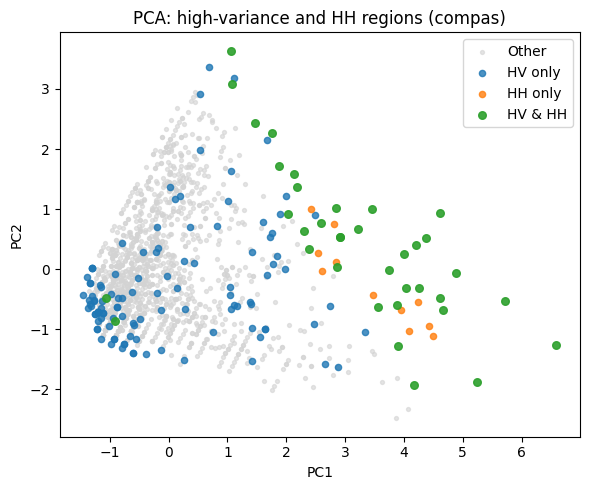

In [17]:
# 1) PCA 2D scatter: HV_q and HH highlighted
pca = PCA(n_components=2, random_state=42)
Xpca = pca.fit_transform(X_test)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Xpca[~HV_q & ~HH, 0], Xpca[~HV_q & ~HH, 1], c="lightgray", s=8, alpha=0.6, label="Other")
ax.scatter(Xpca[HV_only, 0], Xpca[HV_only, 1], c="C0", s=20, alpha=0.8, label="HV only")
ax.scatter(Xpca[HH_only, 0], Xpca[HH_only, 1], c="C1", s=20, alpha=0.8, label="HH only")
ax.scatter(Xpca[HV_q & HH, 0], Xpca[HV_q & HH, 1], c="C2", s=30, alpha=0.9, label="HV & HH")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA: high-variance and HH regions ({dataset_name})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"pca_hv_hh_{dataset_name}.pdf")
plt.show()

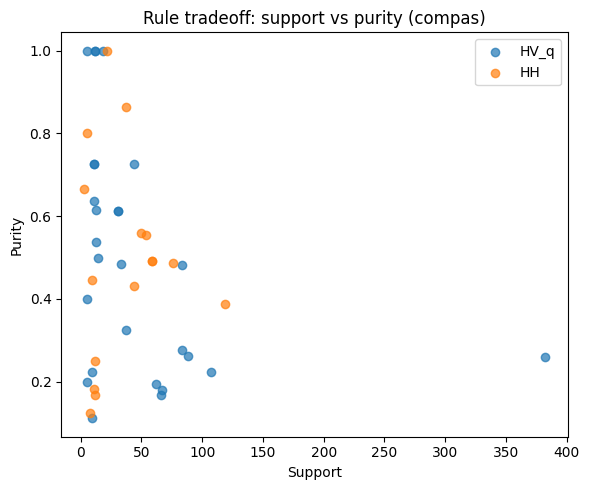

In [18]:
# 2) Rule tradeoff: support vs purity (scatter)
fig, ax = plt.subplots(figsize=(6, 5))
df = rules_summary.dropna(subset=["support", "purity"])
for label in df["label"].unique():
    d = df[df["label"] == label]
    ax.scatter(d["support"], d["purity"], label=label, alpha=0.7)
ax.set_xlabel("Support")
ax.set_ylabel("Purity")
ax.set_title(f"Rule tradeoff: support vs purity ({dataset_name})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / f"rules_support_purity_{dataset_name}.pdf")
plt.show()

In [19]:
# 3) HH connected components: per-component sizes and optional per-component rules
from scipy import sparse
lisa_df = pd.DataFrame({"cluster": np.where(HH_mask, "HH", "NS")})
if W is not None:
    if hasattr(W, "sparse"):
        W_sparse = W.sparse
    else:
        neighbors = getattr(W, "neighbors", {})
        n = len(HH_mask)
        rows, cols, data = [], [], []
        for i in range(n):
            for j in neighbors.get(i, []):
                rows.append(i)
                cols.append(j)
                data.append(1.0)
        W_sparse = sparse.csr_matrix((data, (rows, cols)), shape=(n, n))
    comp_id, components = extract_hh_components(lisa_df, W_sparse)
    if components:
        comp_sizes = [len(components[c]) for c in sorted(components)]
        print(f"HH has {len(components)} connected component(s); sizes: {comp_sizes}")
        for cid in sorted(components):
            idx_c = components[cid]
            y_c = np.zeros(n_test, dtype=int)
            y_c[idx_c] = 1
            _, rules_c = method1_tree(X_test, y_c, feature_names)
            rule_texts = [r[0] for r in rules_c[:2]]
            print(f"  Component {cid} (n={len(idx_c)}): rules = {rule_texts}")
    else:
        print("HH has 0 components (min_size=5) or no HH points.")
else:
    print("W not available; skipping HH components.")

HH has 1 connected component(s); sizes: [45]
  Component 0 (n=45): rules = ['num__priors_count <= 0.8414 AND num__age > 2.812', 'num__priors_count > 0.8414 AND num__age <= 0.2257 AND num__priors_count > 3.844']


## Systematic Driver Analysis (HH vs non-HH)

Train simple classifiers (L1 logistic, shallow tree) to predict HH membership from original features. Purely descriptive: "hotspots are associated with..."

In [20]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in [str(ROOT), str(ROOT / "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis.rules import systematic_driver_analysis
from analysis.run_analysis import load_P_test, select_rashomon_global, run_spatial
from analysis.preprocessing import get_transformed_test_features
from data import load_dataset

RESULTS = ROOT / "results"
TABLES = ROOT / "tables"
K = 25
K_NN = 30
DATASETS = ["compas", "german", "breast_cancer"]
SEEDS = list(range(10))

for ds_name in DATASETS:
    print(f"\n{'='*60}")
    print(f"  Systematic Driver Analysis: {ds_name}")
    print(f"{'='*60}")
    
    ds_dir = RESULTS / ds_name
    X_full, y_full, _ = load_dataset(ds_name)
    
    for seed_val in [0]:  # representative seed
        run_dir = ds_dir / f"seed={seed_val}"
        if not run_dir.exists():
            continue
        
        from analysis.run_analysis import load_split
        split = load_split(run_dir)
        X_test_raw = X_full.iloc[split["test"]].reset_index(drop=True)
        X_test = get_transformed_test_features(run_dir, ds_name)
        
        spatial_res = run_spatial(run_dir, X_test, K=K, k=K_NN, seed=42)
        hh_mask = spatial_res["HH_mask"]
        
        print(f"\n  seed={seed_val}: {hh_mask.sum()} HH points out of {len(hh_mask)}")
        
        results = systematic_driver_analysis(X_test_raw, hh_mask, seed=42)
        
        if "error" in results:
            print(f"    Skipped: {results['error']}")
            continue
        
        for method in ["l1_logistic", "decision_tree"]:
            r = results[method]
            print(f"\n    {method}:")
            print(f"      AUC={r['auc']:.4f}, Precision={r['precision']:.4f}, Recall={r['recall']:.4f}")
            print(f"      Top features:")
            for fname, fval in r["top_features"][:5]:
                print(f"        {fname}: {fval:.4f}")


  Systematic Driver Analysis: compas

  seed=0: 47 HH points out of 1443

    l1_logistic:
      AUC=0.9881, Precision=0.2745, Recall=1.0000
      Top features:
        race_Asian: 6.0085
        race_African-American: -5.5829
        race_Caucasian: -4.7358
        sex_Male: -3.8430
        race_Hispanic: -3.6497

    decision_tree:
      AUC=0.9911, Precision=0.4242, Recall=1.0000
      Top features:
        age: 0.6954
        priors_count: 0.2545
        race_Asian: 0.0501

  Systematic Driver Analysis: german

  seed=0: 3 HH points out of 200
    Skipped: too few HH or non-HH points

  Systematic Driver Analysis: breast_cancer

  seed=0: 0 HH points out of 114
    Skipped: too few HH or non-HH points


## Save outputs

Write tables and figures to `tables/` and `figures/`.

In [21]:
rules_summary.to_csv(TABLE_DIR / f"rules_summary_{dataset_name}.csv", index=False)
rules_oob_summary.to_csv(TABLE_DIR / f"rules_oob_summary_{dataset_name}.csv", index=False)
rules_permutation_pvals.to_csv(TABLE_DIR / f"rules_permutation_pvals_{dataset_name}.csv", index=False)
rule_feature_stability.to_csv(TABLE_DIR / f"rule_feature_stability_{dataset_name}.csv", index=False)
final_rules_table.to_csv(TABLE_DIR / f"final_rules_{dataset_name}.csv", index=False)
print(f"Saved rules_summary, rules_oob_summary, rules_permutation_pvals, rule_feature_stability, final_rules to {TABLE_DIR}")
print(f"Saved {FIG_DIR / f'rules_support_purity_{dataset_name}.pdf'}")
print(f"Saved {FIG_DIR / f'pca_hv_hh_{dataset_name}.pdf'}")

Saved rules_summary, rules_oob_summary, rules_permutation_pvals, rule_feature_stability, final_rules to c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\tables
Saved c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\rules_support_purity_compas.pdf
Saved c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\figures\pca_hv_hh_compas.pdf
